1.import libs

In [25]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                            f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import joblib
import warnings

warnings.filterwarnings('ignore')

print("="*70)
print("Part 2: modeling")
print("="*70)

# load data
df = pd.read_csv('../Data/steam_twitch_final_cleaned.csv')

print(f"\nshape: {df.shape}")
print(f"success game: {df['success'].sum()} ({df['success'].mean()*100:.1f}%)")
print(f"fail game: {(df['success']==0).sum()} ({(df['success']==0).mean()*100:.1f}%)")

Part 2: modeling

shape: (1189, 19)
success game: 592 (49.8%)
fail game: 597 (50.2%)


2. prepare test data

In [26]:

print("\n" + "="*70)
print("1. prepare test data")
print("="*70)

# choose feature（Name and success not include）
feature_columns = [col for col in df.columns if col not in ['Name', 'success']]

X = df[feature_columns]
y = df['success']

print(f"\nfeatures number: {len(feature_columns)}")
print(f"features:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

# find missing valve
if X.isnull().sum().sum() > 0:
    print(f"\ndeal with missing value...")
    X = X.fillna(X.median())
else:
    print(f"\n no missing value")

# divide into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\ndivide into train and test (80% train, 20% test):")
print(f"  train: {len(X_train)} sample ({len(X_train)/len(X)*100:.1f}%)")
print(f"  test: {len(X_test)} sample ({len(X_test)/len(X)*100:.1f}%)")

print(f"\ntrain distribution:")
print(f"  success: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  fail: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")


1. prepare test data

features number: 17
features:
   1. Price
   2. positive_ratio
   3. total_reviews
   4. Achievements
   5. Metacritic_score
   6. platform_count
   7. is_free
   8. Average_playtime_forever
   9. Peak_CCU
  10. Recommendations
  11. Hours_watched
  12. Avg_viewers
  13. Peak_viewers
  14. Streamers
  15. watch_per_stream_hour
  16. streaming_popularity
  17. community_engagement

 no missing value

divide into train and test (80% train, 20% test):
  train: 951 sample (80.0%)
  test: 238 sample (20.0%)

train distribution:
  success: 474 (49.8%)
  fail: 477 (50.2%)


3. decision tree

In [27]:

print("\n" + "="*70)
print("2. Decision Tree Classifier")
print("="*70)

#  train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# test
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"\nDecision Tree trained")
print(f"\ntest score:")
print(f"  Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"  F1 score: {dt_f1:.4f}")

# confusion matrix
print(f"\nconfusion matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

# detailed report
print(f"\ndetailed report:")
print(classification_report(y_test, y_pred_dt, target_names=['fail', 'success']))

# errors
tn, fp, fn, tp = cm_dt.ravel()
print(f"\nerrors:")
print(f"  True Negatives :  {tn}")
print(f"  True Positives :  {tp}")
print(f"  False Positives : {fp}")
print(f"  False Negatives: {fn}")


2. Decision Tree Classifier

Decision Tree trained

test score:
  Accuracy: 0.9748 (97.48%)
  F1 score: 0.9748

confusion matrix:
[[116   4]
 [  2 116]]

detailed report:
              precision    recall  f1-score   support

        fail       0.98      0.97      0.97       120
     success       0.97      0.98      0.97       118

    accuracy                           0.97       238
   macro avg       0.97      0.97      0.97       238
weighted avg       0.97      0.97      0.97       238


errors:
  True Negatives :  116
  True Positives :  116
  False Positives : 4
  False Negatives: 2


4.random forest

In [28]:

print("\n" + "="*70)
print("3. Random Forest Classifier")
print("="*70)

# train random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# test
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"\nRandom Forest trained")
print(f"\ntest report:")
print(f"  Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"  F1 score: {rf_f1:.4f}")

# confusion_matrix
print(f"\nconfusion_matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# report
print(f"\nreport:")
print(classification_report(y_test, y_pred_rf, target_names=['fail', 'success']))

# error report
tn, fp, fn, tp = cm_rf.ravel()
print(f"\nerror report:")
print(f"  False Positives : {fp} ")
print(f"  False Negatives : {fn} ")
print(f"  True Positives : {tp} ")
print(f"  True Negatives : {tn} ")


3. Random Forest Classifier

Random Forest trained

test report:
  Accuracy: 0.9748 (97.48%)
  F1 score: 0.9744

confusion_matrix:
[[118   2]
 [  4 114]]

report:
              precision    recall  f1-score   support

        fail       0.97      0.98      0.98       120
     success       0.98      0.97      0.97       118

    accuracy                           0.97       238
   macro avg       0.97      0.97      0.97       238
weighted avg       0.97      0.97      0.97       238


error report:
  False Positives : 2 
  False Negatives : 4 
  True Positives : 114 
  True Negatives : 118 


5. Naive bayes

In [29]:

print("\n" + "="*70)
print("4. Naive Bayes Classifier ")
print("="*70)

# Naive Bayes need standard
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# predict
y_pred_nb = nb_model.predict(X_test_scaled)

# test
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print(f"\nNaive Bayes trained")
print(f"\nreport:")
print(f"  Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")
print(f"  F1 score: {nb_f1:.4f}")

# confusion_matrix
print(f"\nconfusion_matrix:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)


# detailed report
print(f"\ndetailed report:")

print(classification_report(y_test, y_pred_nb, target_names=['fail', 'success']))

# errors
tn, fp, fn, tp = cm_nb.ravel()
print(f"\nerrors:")
print(f"  True Negatives :  {tn}")
print(f"  True Positives :  {tp}")
print(f"  False Positives : {fp}")
print(f"  False Negatives: {fn}")


4. Naive Bayes Classifier 

Naive Bayes trained

report:
  Accuracy: 0.8950 (89.50%)
  F1 score: 0.8918

confusion_matrix:
[[110  10]
 [ 15 103]]

detailed report:
              precision    recall  f1-score   support

        fail       0.88      0.92      0.90       120
     success       0.91      0.87      0.89       118

    accuracy                           0.89       238
   macro avg       0.90      0.89      0.89       238
weighted avg       0.90      0.89      0.89       238


errors:
  True Negatives :  110
  True Positives :  103
  False Positives : 10
  False Negatives: 15


5.5 XGboost

In [30]:

print("\n" + "="*70)
print("5. XGBoost Classifier ")
print("="*70)

try:
    from xgboost import XGBClassifier

    # train
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'  # avoid error, do not delete
    )

    print("Training XGBoost model...")
    xgb_model.fit(X_train, y_train)

    # predict
    y_pred_xgb = xgb_model.predict(X_test)

    # test
    xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
    xgb_f1 = f1_score(y_test, y_pred_xgb)

    print(f"\nXGBoost trained")
    print(f"\nreport:")
    print(f"  Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
    print(f"  F1 score: {xgb_f1:.4f}")

    # confusion_matrix
    print(f"\nconfusion_matrix:")
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    print(cm_xgb)

    # report
    print(f"\nclassification_report:")
    print(classification_report(y_test, y_pred_xgb, target_names=['fail', 'success']))

    # errors
    tn, fp, fn, tp = cm_xgb.ravel()
    print(f"\nerrors:")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives : {fn}")
    print(f"  True Positives : {tp}")
    print(f"  True Negatives : {tn}")

    xgb_available = True

except ImportError:
    print("XGBoost is not available")
    print("how to install: pip install xgboost")
    xgb_available = False
    xgb_accuracy = 0
    xgb_f1 = 0
    cm_xgb = np.zeros((2, 2))


5. XGBoost Classifier 
Training XGBoost model...

XGBoost trained

report:
  Accuracy: 0.9790 (97.90%)
  F1 score: 0.9787

confusion_matrix:
[[118   2]
 [  3 115]]

classification_report:
              precision    recall  f1-score   support

        fail       0.98      0.98      0.98       120
     success       0.98      0.97      0.98       118

    accuracy                           0.98       238
   macro avg       0.98      0.98      0.98       238
weighted avg       0.98      0.98      0.98       238


errors:
  False Positives: 2
  False Negatives : 3
  True Positives : 115
  True Negatives : 118


6. compare between models


6. compare between models

compare frame:
        Model  Accuracy  F1-Score  False Positives  False Negatives
      XGBoost  0.978992  0.978723                2                3
Decision Tree  0.974790  0.974790                4                2
Random Forest  0.974790  0.974359                2                4
  Naive Bayes  0.894958  0.891775               10               15


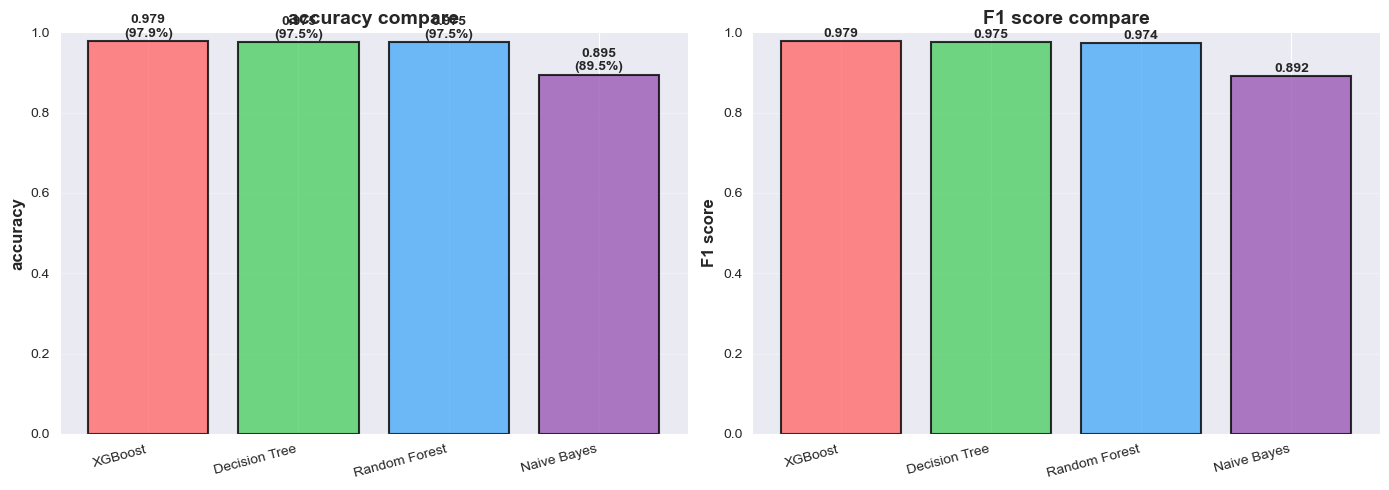


saved as: model_comparison.png

best model: XGBoost
   accuracy: 0.9790 (97.90%)
   F1 score: 0.9787
 even if random forest has same accuracy compare with XGBoost, less fp makes developer save money on fail games.


In [31]:

print("\n" + "="*70)
print("6. compare between models")
print("="*70)

# create compare frame
if xgb_available:
    results = pd.DataFrame({
        'Model': ['Decision Tree', 'Random Forest', 'Naive Bayes', 'XGBoost'],
        'Accuracy': [dt_accuracy, rf_accuracy, nb_accuracy, xgb_accuracy],
        'F1-Score': [dt_f1, rf_f1, nb_f1, xgb_f1],
        'False Positives': [cm_dt[0,1], cm_rf[0,1], cm_nb[0,1], cm_xgb[0,1]],
        'False Negatives': [cm_dt[1,0], cm_rf[1,0], cm_nb[1,0], cm_xgb[1,0]]
    })
    colors = ['#ff6b6b', '#51cf66', '#4dabf7', '#9b59b6']
else:
    results = pd.DataFrame({
        'Model': ['Decision Tree', 'Random Forest', 'Naive Bayes'],
        'Accuracy': [dt_accuracy, rf_accuracy, nb_accuracy],
        'F1-Score': [dt_f1, rf_f1, nb_f1],
        'False Positives': [cm_dt[0,1], cm_rf[0,1], cm_nb[0,1]],
        'False Negatives': [cm_dt[1,0], cm_rf[1,0], cm_nb[1,0]]
    })
    colors = ['#ff6b6b', '#51cf66', '#4dabf7']

results = results.sort_values('Accuracy', ascending=False)
print("\ncompare frame:")
print(results.to_string(index=False))

# visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy
bars1 = axes[0].bar(range(len(results)), results['Accuracy'],
                    color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(results)))
axes[0].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[0].set_ylabel('accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('accuracy compare', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# set label
for bar, val in zip(bars1, results['Accuracy']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}\n({val*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

# F1 score
bars2 = axes[1].bar(range(len(results)), results['F1-Score'],
                    color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(results)))
axes[1].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[1].set_ylabel('F1 score', fontsize=12, fontweight='bold')
axes[1].set_title('F1 score compare', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

# set label
for bar, val in zip(bars2, results['F1-Score']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nsaved as: model_comparison.png")

# choose best model
best_model_name = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
best_f1 = results.iloc[0]['F1-Score']

print(f"\nbest model: {best_model_name}")
print(f"   accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   F1 score: {best_f1:.4f}")
print(f" even if random forest has same accuracy compare with XGBoost, less fp makes developer save money on fail games.")

 7. ConfusionMatrix Visualize


7. ConfusionMatrix Visualize


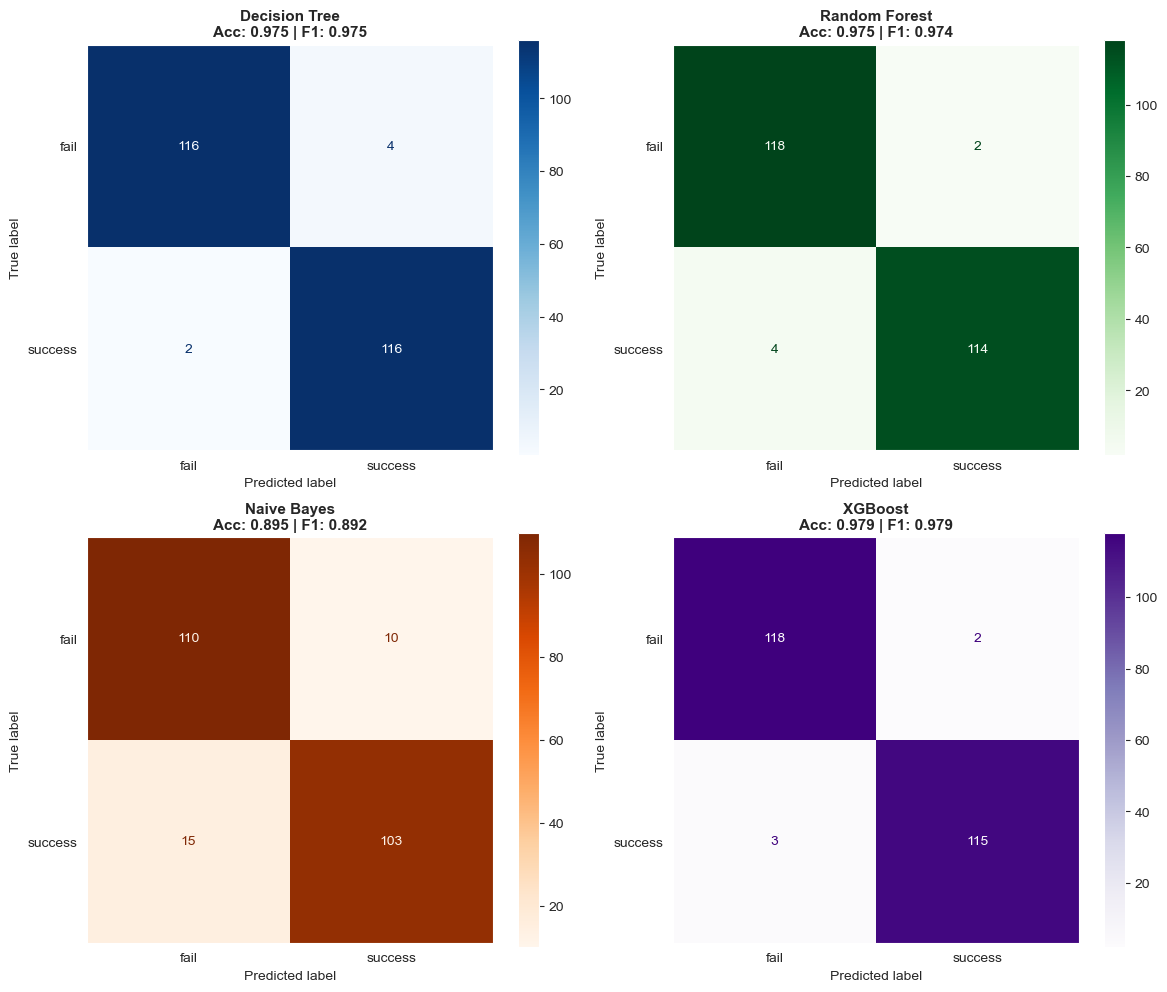


saved as: confusion_matrices.png


In [32]:

print("\n" + "="*70)
print("7. ConfusionMatrix Visualize")
print("="*70)

if xgb_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    # Decision Tree
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['fail', 'success'])
    disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'Decision Tree\nAcc: {dt_accuracy:.3f} | F1: {dt_f1:.3f}', 
                     fontsize=11, fontweight='bold')
    axes[0].grid(False)
    
    # Random Forest
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['fail', 'success'])
    disp2.plot(ax=axes[1], cmap='Greens', values_format='d')
    axes[1].set_title(f'Random Forest\nAcc: {rf_accuracy:.3f} | F1: {rf_f1:.3f}', 
                     fontsize=11, fontweight='bold')
    axes[1].grid(False)
    
    # Naive Bayes
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['fail', 'success'])
    disp3.plot(ax=axes[2], cmap='Oranges', values_format='d')
    axes[2].set_title(f'Naive Bayes\nAcc: {nb_accuracy:.3f} | F1: {nb_f1:.3f}', 
                     fontsize=11, fontweight='bold')
    axes[2].grid(False)
    
    # XGBoost
    disp4 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['fail', 'success'])
    disp4.plot(ax=axes[3], cmap='Purples', values_format='d')
    axes[3].set_title(f'XGBoost\nAcc: {xgb_accuracy:.3f} | F1: {xgb_f1:.3f}', 
                     fontsize=11, fontweight='bold')
    axes[3].grid(False)
    
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Decision Tree
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['fail', 'success'])
    disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'Decision Tree\nAcc: {dt_accuracy:.3f}', fontsize=12, fontweight='bold')
    axes[0].grid(False)
    
    # Random Forest
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['fail', 'success'])
    disp2.plot(ax=axes[1], cmap='Greens', values_format='d')
    axes[1].set_title(f'Random Forest\nAcc: {rf_accuracy:.3f}', fontsize=12, fontweight='bold')
    axes[1].grid(False)
    
    # Naive Bayes
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['fail', 'success'])
    disp3.plot(ax=axes[2], cmap='Oranges', values_format='d')
    axes[2].set_title(f'Naive Bayes\nAcc: {nb_accuracy:.3f}', fontsize=12, fontweight='bold')
    axes[2].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nsaved as: confusion_matrices.png")

7.5 error explain

In [42]:
    print("\n" + "="*70)
    print("7.5 Model Errors Analysis - XGBoost")
    print("="*70)

    # Find FP examples
    y_pred_xgb_analysis = xgb_model.predict(X_test)
    fp_mask = (y_pred_xgb_analysis == 1) & (y_test == 0)

    if fp_mask.sum() > 0:
        fp_indices = X_test.index[fp_mask][:5]
        print(f"\nFalse Positive Examples:")

        for idx in fp_indices:
            game_name = df.loc[idx, 'Name']
            pos_ratio = df.loc[idx, 'positive_ratio']
            reviews = df.loc[idx, 'total_reviews']
            recs = df.loc[idx, 'Recommendations']

            print(f"\n  • {game_name}")
            print(f"    positive_ratio: {pos_ratio:.3f} {'yes (≥0.85)' if pos_ratio >= 0.85 else ' no(<0.85)'}")
            print(f"    total_reviews: {reviews:.0f}")
            print(f"    Recommendations: {recs:.0f} {' yes(≥1000)' if recs >= 1000 else 'no (<1000)'}")

            if pos_ratio >= 0.85 and recs < 1000:
                print(f"    Reason: High quality (85%+) but low recommendations (<1000)")

    print(f"\Why False Positives occur:")
    print(f"  • Model focuses on high positive_ratio")
    print(f"  • Overlooks insufficient recommendation count")
    print(f"  • High Twitch views may mislead the model")

    print("\n" + "="*70)
    print("False Negatives (FN)")
    print("="*70)
    print(f"Count: {fn} ({fn/len(y_test)*100:.1f}%)")
    print(f"Definition: Model predicts failure, but game actually succeeds")
    print(f"Business impact: Missing potentially successful games")

    # Find FN examples
    fn_mask = (y_pred_xgb_analysis == 0) & (y_test == 1)

    if fn_mask.sum() > 0:
        fn_indices = X_test.index[fn_mask][:5]
        print(f"\nFalse Negative Examples:")

        for idx in fn_indices:
            game_name = df.loc[idx, 'Name']
            pos_ratio = df.loc[idx, 'positive_ratio']
            reviews = df.loc[idx, 'total_reviews']
            recs = df.loc[idx, 'Recommendations']
            hours = df.loc[idx, 'Hours_watched']

            print(f"\n  • {game_name}")
            print(f"    positive_ratio: {pos_ratio:.3f} ")
            print(f"    total_reviews: {reviews:.0f}")
            print(f"    Recommendations: {recs:.0f} ")
            print(f"    Hours_watched: {hours:.0f}")

            if reviews < 500:
                print(f"    Reason: Low review count, model underestimated")
            elif hours < 1000000:
                print(f"    Reason: Low Twitch visibility, model underestimated")

    print(f"\nWhy False Negatives occur:")
    print(f"  • High-quality niche games with low visibility")
    print(f"  • Low total_reviews count misleads model")
    print(f"  • Low Twitch presence underestimates success")

    print("\n" + "="*70)
    print(" Error Rates")
    print("="*70)
    print(f"False Positive Rate: {fp/(fp+tn)*100:.2f}% (among actual failures)")
    print(f"False Negative Rate: {fn/(fn+tp)*100:.2f}% (among actual successes)")

    print("\n Model errors analysis complete")


7.5 Model Errors Analysis - XGBoost

False Positive Examples:

  • The Infectious Madness of Doctor Dekker
    positive_ratio: 0.854 yes (≥0.85)
    total_reviews: 465
    Recommendations: 413 no (<1000)
    Reason: High quality (85%+) but low recommendations (<1000)

  • ONE PIECE ODYSSEY
    positive_ratio: 0.856 yes (≥0.85)
    total_reviews: 769
    Recommendations: 642 no (<1000)
    Reason: High quality (85%+) but low recommendations (<1000)
\Why False Positives occur:
  • Model focuses on high positive_ratio
  • Overlooks insufficient recommendation count
  • High Twitch views may mislead the model

False Negatives (FN)
Count: 3 (1.3%)
Definition: Model predicts failure, but game actually succeeds
Business impact: Missing potentially successful games

False Negative Examples:

  • Stilt Fella
    positive_ratio: 0.920 
    total_reviews: 773
    Recommendations: 689 
    Hours_watched: 1632057

  • Lost Judgment
    positive_ratio: 0.933 
    total_reviews: 165
    Recommendati

8. ROC curve



8. ROC curve 


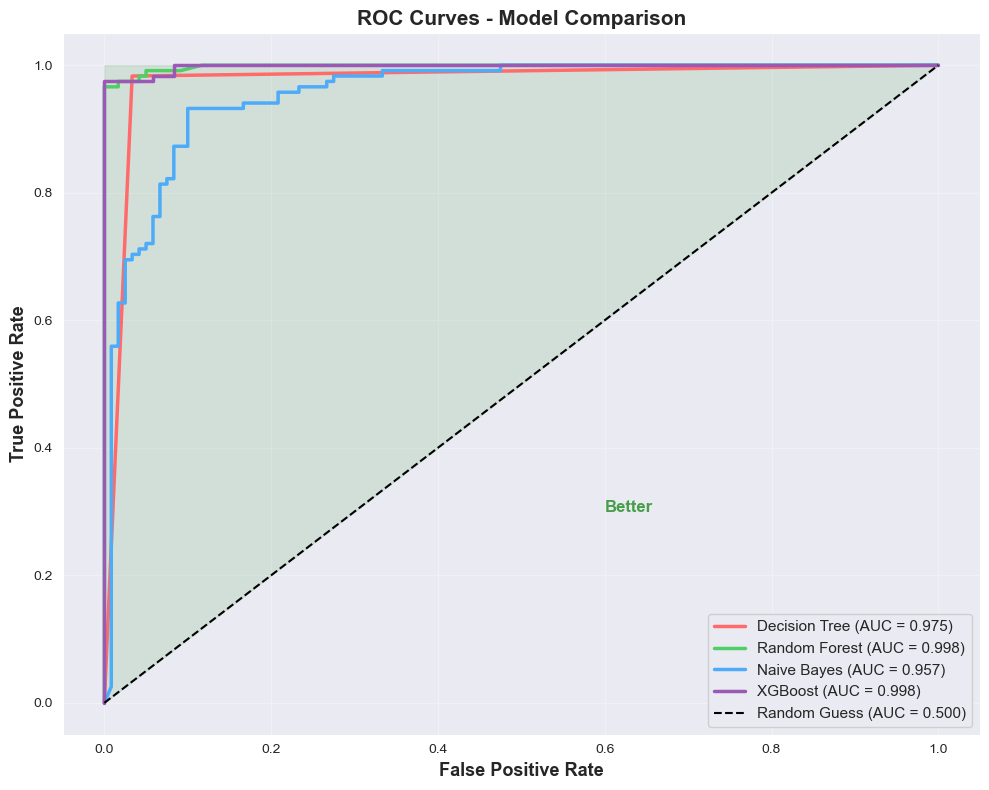


saved as: roc_curves.png

AUC compare:
  Decision Tree: 0.9749
  Random Forest: 0.9982
  Naive Bayes:   0.9565
  XGBoost:       0.9981


In [35]:

print("\n" + "="*70)
print("8. ROC curve ")
print("="*70)

# get predict probability
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# calculate roc curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)

# calculate AUC
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_nb = auc(fpr_nb, tpr_nb)

# XGBoost ROC
if xgb_available:
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
    auc_xgb = auc(fpr_xgb, tpr_xgb)

# draw ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})',
         linewidth=2.5, color='#ff6b6b')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})',
         linewidth=2.5, color='#51cf66')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})',
         linewidth=2.5, color='#4dabf7')

if xgb_available:
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})',
             linewidth=2.5, color='#9b59b6')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)

# set
plt.fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color='green', label='_nolegend_')
plt.text(0.6, 0.3, 'Better', fontsize=12, color='green', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nsaved as: roc_curves.png")
print(f"\nAUC compare:")
print(f"  Decision Tree: {auc_dt:.4f}")
print(f"  Random Forest: {auc_rf:.4f}")
print(f"  Naive Bayes:   {auc_nb:.4f}")
if xgb_available:
    print(f"  XGBoost:       {auc_xgb:.4f}")

9. hyper parameter


In [44]:
#
print("\n" + "="*70)
print("10. Hyperparameter Tuning ")
print("="*70)

# Random Forest Tuning
print("\n" + "="*70)
print("Tuning Random Forest")
print("="*70)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print(f"Parameter grid: {3 * 3 * 2 * 2} = 36 combinations")
print("Starting grid search with 5-fold cross-validation...")

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train, y_train)

print(f"\nRandom Forest tuning complete")
print(f"\nBest parameters:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

best_rf_tuned = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_tuned.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)

print(f"\nTuned model performance:")
print(f"  Accuracy: {rf_tuned_accuracy:.4f} ({rf_tuned_accuracy*100:.2f}%)")
print(f"  F1-Score: {rf_tuned_f1:.4f}")
print(f"  Improvement: {(rf_tuned_accuracy - rf_accuracy)*100:+.2f}%")

# XGBoost Tuning
if xgb_available:
    print("\n" + "="*70)
    print("Tuning XGBoost")
    print("="*70)

    param_grid_xgb = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }

    print(f"Parameter grid: {3 * 3 * 3 * 2} = 54 combinations")
    print("Starting grid search with 5-fold cross-validation...")

    grid_search_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid_xgb,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search_xgb.fit(X_train, y_train)

    print(f"\nXGBoost tuning complete")
    print(f"\nBest parameters:")
    for param, value in grid_search_xgb.best_params_.items():
        print(f"  {param}: {value}")

    best_xgb_tuned = grid_search_xgb.best_estimator_
    y_pred_xgb_tuned = best_xgb_tuned.predict(X_test)
    xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
    xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned)

    print(f"\nTuned model performance:")
    print(f"  Accuracy: {xgb_tuned_accuracy:.4f} ({xgb_tuned_accuracy*100:.2f}%)")
    print(f"  F1-Score: {xgb_tuned_f1:.4f}")
    print(f"  Improvement: {(xgb_tuned_accuracy - xgb_accuracy)*100:+.2f}%")

print("\nHyperparameter tuning complete")


10. Hyperparameter Tuning 

Tuning Random Forest
Parameter grid: 36 = 36 combinations
Starting grid search with 5-fold cross-validation...

Random Forest tuning complete

Best parameters:
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100

Tuned model performance:
  Accuracy: 0.9790 (97.90%)
  F1-Score: 0.9785
  Improvement: +0.42%

Tuning XGBoost
Parameter grid: 54 = 54 combinations
Starting grid search with 5-fold cross-validation...

XGBoost tuning complete

Best parameters:
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 100
  subsample: 1.0

Tuned model performance:
  Accuracy: 0.9790 (97.90%)
  F1-Score: 0.9785
  Improvement: +0.00%

Hyperparameter tuning complete


10. save best model


In [47]:
import os

print("\n" + "="*70)
print("11. Save Best Model")
print("="*70)

print("\nModel Selection:")
print("-" * 70)

# compare all models
all_results = {
    'Decision Tree': {'accuracy': dt_accuracy, 'f1': dt_f1, 'model': dt_model},
    'Random Forest': {'accuracy': rf_accuracy, 'f1': rf_f1, 'model': rf_model},
    'Naive Bayes': {'accuracy': nb_accuracy, 'f1': nb_f1, 'model': nb_model},
}

if xgb_available:
    all_results['XGBoost'] = {'accuracy': xgb_accuracy, 'f1': xgb_f1, 'model': xgb_model}

print("\nAll models performance:")
for model_name, metrics in sorted(all_results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"  {model_name:<20} Accuracy: {metrics['accuracy']:.4f}  F1: {metrics['f1']:.4f}")

# choose best model
best_model_name = max(all_results, key=lambda k: all_results[k]['accuracy'])
final_model = all_results[best_model_name]['model']
final_accuracy = all_results[best_model_name]['accuracy']
final_f1 = all_results[best_model_name]['f1']

print(f"\nBest Model: {best_model_name}")
print(f"\nModel Performance:")
print(f"  • Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"  • F1-Score: {final_f1:.4f}")

if xgb_available and best_model_name == 'XGBoost':
    print(f"  • AUC Score: {auc_xgb:.4f}")

elif best_model_name == 'Random Forest':
    print(f"  • AUC Score: {auc_rf:.4f}")

# Ensure Model directory exists
model_dir = '../Model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"\nCreated directory: {model_dir}")

# Save model
model_path = os.path.join(model_dir, 'best_model.pkl')
joblib.dump(final_model, model_path)
print(f"\nModel saved: {model_path}")

# Save feature list
feature_list_path = os.path.join(model_dir, 'feature_columns.pkl')
joblib.dump(feature_columns, feature_list_path)
print(f"Feature list saved: {feature_list_path}")

# Save model info
model_info = {
    'model_name': best_model_name,
    'model_type': type(final_model).__name__,
    'accuracy': float(final_accuracy),
    'f1_score': float(final_f1),
    'auc_score': float(auc_xgb if best_model_name == 'XGBoost' else auc_rf),
    'n_features': len(feature_columns),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test),
    'feature_columns': feature_columns,
}

if best_model_name == 'XGBoost':
    model_info['hyperparameters'] = {
        'n_estimators': final_model.n_estimators,
        'max_depth': final_model.max_depth,
        'learning_rate': final_model.learning_rate,
        'random_state': final_model.random_state
    }
else:
    model_info['hyperparameters'] = {
        'n_estimators': final_model.n_estimators,
        'max_depth': final_model.max_depth,
        'random_state': final_model.random_state
    }

info_path = os.path.join(model_dir, 'model_info.pkl')
joblib.dump(model_info, info_path)
print(f"Model info saved: {info_path}")

# Display saved files
print(f"\nContents of Model directory:")
for file in sorted(os.listdir(model_dir)):
    file_path = os.path.join(model_dir, file)
    file_size = os.path.getsize(file_path) / 1024
    print(f"  • {file:<25} ({file_size:.1f} KB)")

print(f"\nBest model ({best_model_name}) saved successfully")


11. Save Best Model

Model Selection:
----------------------------------------------------------------------

All models performance:
  XGBoost              Accuracy: 0.9790  F1: 0.9787
  Decision Tree        Accuracy: 0.9748  F1: 0.9748
  Random Forest        Accuracy: 0.9748  F1: 0.9744
  Naive Bayes          Accuracy: 0.8950  F1: 0.8918

Best Model: XGBoost

Model Performance:
  • Accuracy: 0.9790 (97.90%)
  • F1-Score: 0.9787
  • AUC Score: 0.9981

Model saved: ../Model\best_model.pkl
Feature list saved: ../Model\feature_columns.pkl
Model info saved: ../Model\model_info.pkl

Contents of Model directory:
  • best_model.pkl            (113.9 KB)
  • feature_columns.pkl       (0.3 KB)
  • model_info.pkl            (0.6 KB)

Best model (XGBoost) saved successfully
